In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/multitask_preplay/figures
changing to root directory
at directory: /Users/wilka/git/research/multitask_preplay


In [3]:
sys.path.append("simulations")

In [4]:
from analysis import jaxmaze_analysis
import data_configs
import plot_configs

No file specified for image dict.
Using: /Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/housemaze/image_data.pkl


In [5]:
import data_configs
from data_processing.utils import download_jaxmaze_data
print("Data will be downloaded or saved to", data_configs.DIRECTORY)
download_jaxmaze_data()

Data will be downloaded or saved to ../preplay_results


Using custom data configuration wcarvalho--Multitask_Preplay_JaxMaze_human-38d3e6d7048fd340
Reusing dataset parquet (/Users/wilka/.cache/huggingface/datasets/wcarvalho___parquet/wcarvalho--Multitask_Preplay_JaxMaze_human-38d3e6d7048fd340/0.0.0/0b6d5799bb726b24ad7fc7be720c170d8e497f575d02d47537de9a5bac074901)


  0%|          | 0/2 [00:00<?, ?it/s]

Skipping train data because it already exists
Skipping human_data data because it already exists


Using custom data configuration wcarvalho--Multitask_Preplay_JaxMaze_models-4f3726c2642b7ecb
Reusing dataset parquet (/Users/wilka/.cache/huggingface/datasets/wcarvalho___parquet/wcarvalho--Multitask_Preplay_JaxMaze_models-4f3726c2642b7ecb/0.0.0/0b6d5799bb726b24ad7fc7be720c170d8e497f575d02d47537de9a5bac074901)


  0%|          | 0/6 [00:00<?, ?it/s]

Skipping usfa data because it already exists
Skipping dfs data because it already exists
Skipping dyna data because it already exists
Skipping qlearning data because it already exists
Skipping preplay data because it already exists
Skipping bfs data because it already exists


# Load data

In [6]:
from data_processing import process_model_data

model_df = process_model_data.get_jaxmaze_model_data()
model_df.head()

Loading textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
Textures successfully loaded from cache.
No file specified for groups.
Using: /Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/housemaze/human_dyna/list_of_groups.npy
Generating model data for qlearning
Generating model data for dyna
Generating model data for usfa
Generating model data for preplay
Generating model data for bfs
Generating model data for dfs


domain,algo,user_id,manipulation,world,block_name,condition,task_set,global_episode_idx,corresponding_train_episode_idx,success,overlap,eval,start_pos,total_reward,path_length,task_vector,task_object_id,reuse
str,str,i64,str,str,str,i64,i64,i64,i32,f64,f64,bool,str,f64,i64,str,i64,i32
"""jaxmaze""","""qlearning""",1,"""paths""","""big_m3_maze1""","""reverse(H=False,W=False)""",0,0,0,-1,1.0,NaN,false,"""[17 1]""",1.0,89,"""[0 1 0 0]""",40,-1
"""jaxmaze""","""qlearning""",1,"""paths""","""big_m3_maze1""","""reverse(H=False,W=False)""",0,0,1,-1,1.0,NaN,false,"""[17 1]""",1.0,98,"""[0 1 0 0]""",40,-1
"""jaxmaze""","""qlearning""",1,"""paths""","""big_m3_maze1""","""reverse(H=False,W=False)""",0,0,2,-1,1.0,NaN,false,"""[17 1]""",1.0,93,"""[0 1 0 0]""",40,-1
"""jaxmaze""","""qlearning""",1,"""paths""","""big_m3_maze1""","""reverse(H=False,W=False)""",0,0,3,-1,1.0,NaN,false,"""[17 1]""",1.0,111,"""[0 1 0 0]""",40,-1
"""jaxmaze""","""qlearning""",1,"""paths""","""big_m3_maze1""","""reverse(H=False,W=False)""",0,0,4,-1,1.0,NaN,false,"""[17 1]""",1.0,91,"""[0 1 0 0]""",40,-1


In [7]:
from data_processing import process_user_data

user_df = process_user_data.get_jaxmaze_human_data()
# user_df.filter(eval=True).head()

No file specified for image dict.
Using: /Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/housemaze/image_data.pkl
GENERATING ../preplay_results/data/jaxmaze/final/human_data_episode_df.parquet
LOADING ../preplay_results/data/jaxmaze/final/human_data_episode_df.parquet


# Analysis

Num initial users:  115
Loading cached user IDs from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/path_reuse_results_user_ids.pkl
Num users after cache filter:  100
Removed 107 global episode indices
Removed 0 global episode indices


/Users/wilka/git/research/multitask_preplay/analysis/analysis_utils.py:1281: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  _, normality_p = stats.shapiro(rates)
/Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


Removed 107 global episode indices
Mean reuse:  0.6238532110091743
Filtered 107 rows with null success or reuse
Loading cached results from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/statsfile.first_log_rt_reuse_1000_0.5.pkl
n no_reuse: 58
n reuse: 77


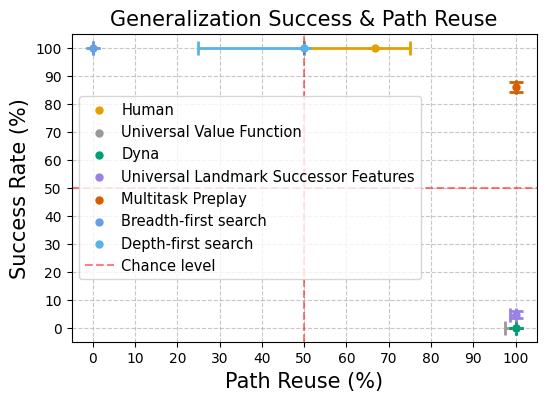

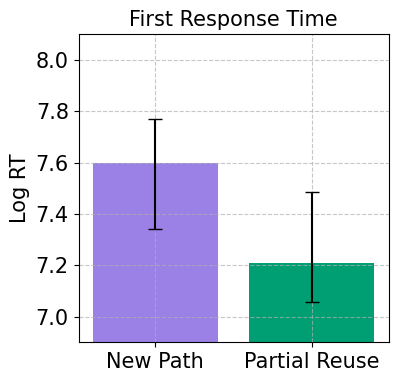

Removed 107 global episode indices
Mean reuse:  0.6238532110091743
Filtered 107 rows with null success or reuse
Loading cached results from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/statsfile.max_log_rt_reuse_1000_0.5.pkl
n no_reuse: 58
n reuse: 77


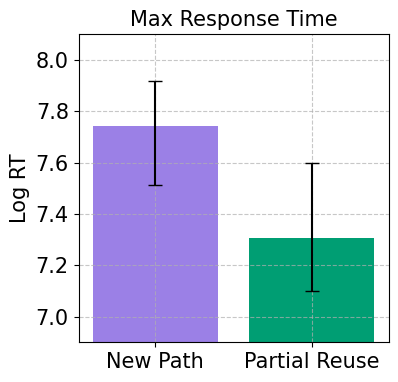

In [24]:
jaxmaze_analysis.path_reuse_results(
  user_df,
  model_df,
  save_dir=data_configs.JAXMAZE_RESULTS_DIR,
  tell_reuse=1,
  display_figs=True,
  save_figs=True,
  n_simulations=1000,
  verbosity=0,
  rereun_analysis=False,
  overlap_threshold=0.5,
)

Num initial users:  105
Loading cached user IDs from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/shortcut_results_user_ids.pkl
Num users after cache filter:  100
Removed 88 global episode indices
Removed 0 global episode indices


/Users/wilka/git/research/multitask_preplay/analysis/analysis_utils.py:1281: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  _, normality_p = stats.shapiro(rates)


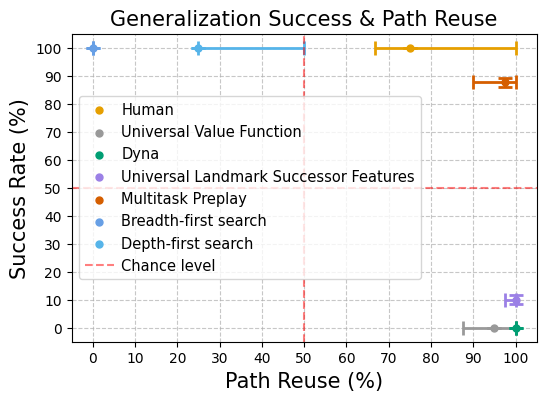

In [23]:
jaxmaze_analysis.shortcut_results(
    user_df,
    model_df,
    overlap_threshold=.6,
    save_figs=True)

Num initial users:  114
Loading cached user IDs from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/start_results_user_ids.pkl
Num users after cache filter:  100


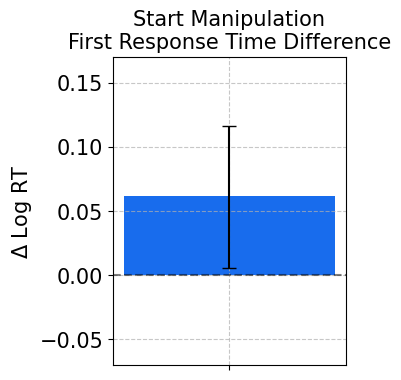

In [26]:
jaxmaze_analysis.start_results(
  user_df,
  ylim=[-0.05, 0.15],
)

No file specified for image dict.
Using: /Users/wilka/git/research/multitask_preplay/.venv/lib/python3.11/site-packages/housemaze/image_data.pkl
Loading cached user IDs from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/juncture_results_tell_reuse_user_ids.pkl
Num users after cache filter:  200


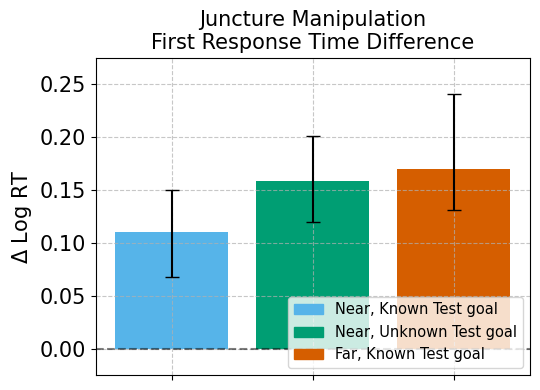

In [30]:
jaxmaze_analysis.juncture_results(
    user_df,
    ylim=[0, 0.25],
)